In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/filip/Git_Code/')
sys.path.append('/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/')

from demler_tools.file_manager import path_management, io
import data_analysis as da

/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/data_analysis.py:400: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_title(f'Real($\Delta$) - {title_suffix}', fontsize=13)
/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/data_analysis.py:407: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_title(f'Imag($\Delta$) - {title_suffix}', fontsize=13)
/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP-keldysh/data_analysis.py:414: SyntaxWarning: invalid escape sequence '\D'
  axes[2].set_title(f'$|\Delta|$ - {title_suffix}', fontsize=13)


In [2]:
# Initialize demler_tools path management
path_management.initialize(project_name='psBQP-keldysh')

Successfully initialized path management with following parameters:
     username:                fmarijanovic
     project name:            psBQP-keldysh
     controlling machine:     laptop
     library version:         v2.3.0-beta-3-gb5c5e8d
     auto SSH transfer:       True
     default save location:   /home/filip/Documents/Research/data_files/
     LTS mount point:         /home/filip
     email domain:            phys.ethz.ch
     cluster OS:              Ubuntu
     cluster partition:       work
     SSH host file:           /home/filip/.ssh/known_hosts
     SSH key file:            /home/filip/.ssh/id_ed25519_euler
     default modules:         {'CentOS': 'gcc/8.2.0 python/3.11.2', 'Ubuntu': 'stack/2024-06 python/3.11.6'}


In [13]:
#check_timestamp = '1780759388'  # Timestamp folder to analyze -- refernce one from equilibrium
check_timestamp = '1780820543' #'1780771986'
check_job_index = 0              # Job index to analyze
print(f"Analyzing timestamp: {check_timestamp}, job index: {check_job_index}")

Analyzing timestamp: 1780820543, job index: 0


# 1. Validation Checks

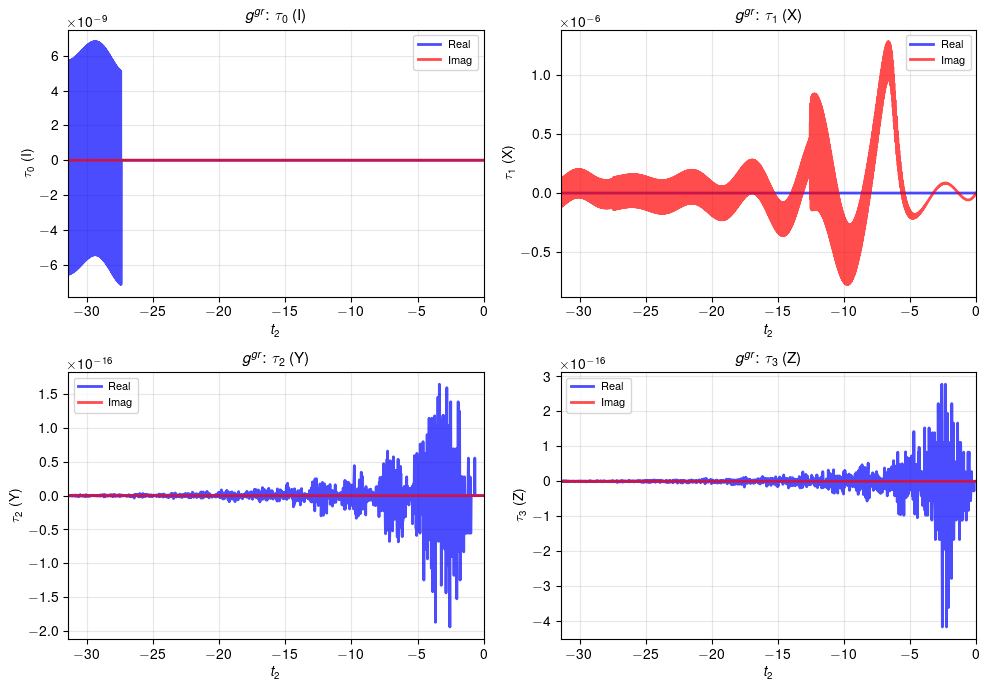

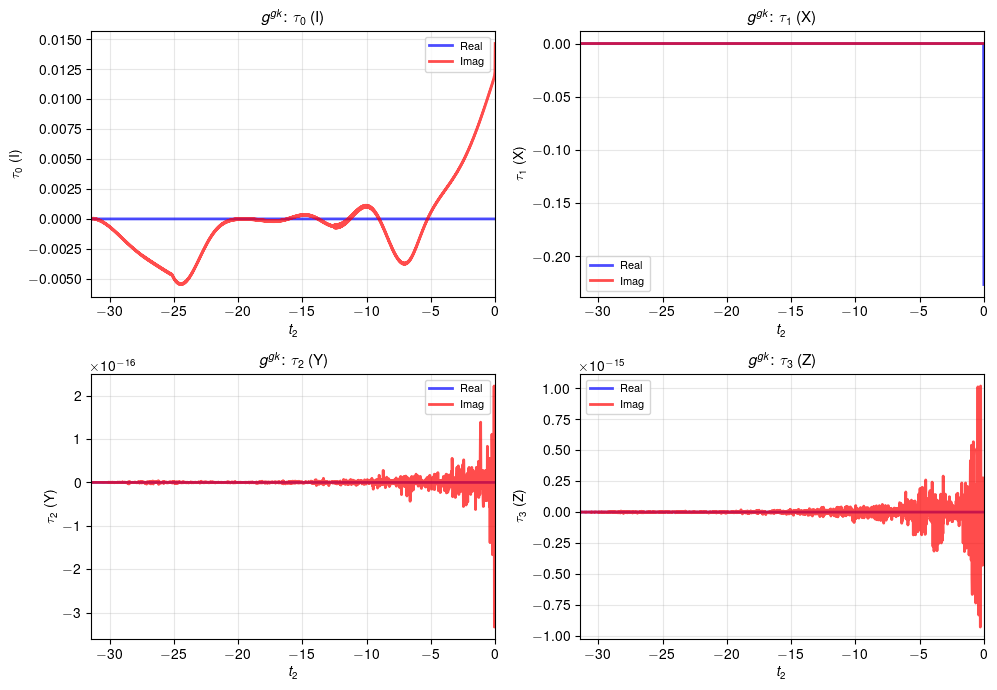


Normalization Check Results:
  gr errors per channel:
    τ₀: 1.00e+00
    τ₁: 1.28e-06
    τ₂: 1.94e-16
    τ₃: 4.16e-16
  gr max error: 1.00e+00 (in channel τ₀)

  gk errors per channel:
    τ₀: 1.47e-02
    τ₁: 2.26e-01
    τ₂: 3.33e-16
    τ₃: 1.02e-15
  gk max error: 2.26e-01 (in channel τ₁)


In [14]:
# Check gr and gk normalization relations
norm_results = da.check_normalizations(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']

print(f"\nNormalization Check Results:")
print(f"  gr errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gr_max_error'][i]:.2e}")
gr_max_idx = np.argmax(norm_results['gr_max_error'])
print(f"  gr max error: {norm_results['gr_max_error'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {norm_results['gk_max_error'][i]:.2e}")
gk_max_idx = np.argmax(norm_results['gk_max_error'])
print(f"  gk max error: {norm_results['gk_max_error'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")

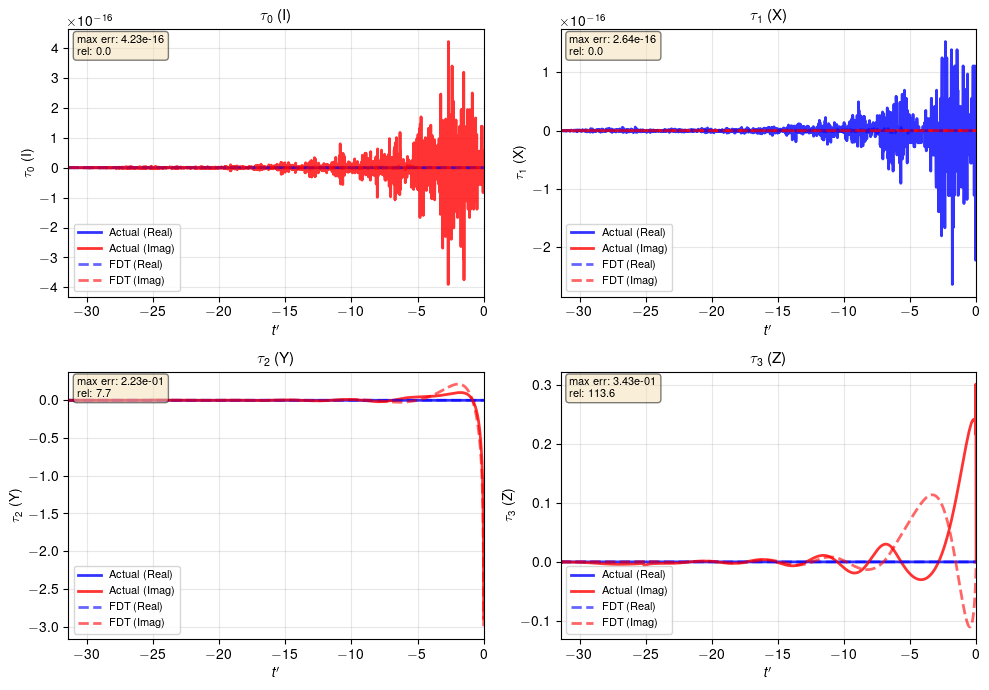


FDT Check Results:
  Errors per channel:
    τ₀: 4.23e-16
    τ₁: 2.64e-16
    τ₂: 2.23e-01
    τ₃: 3.43e-01
  Max error: 3.43e-01 (in channel τ₃)


In [15]:
# Check fluctuation-dissipation theorem
fdt_results = da.check_fdt(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nFDT Check Results:")
print(f"  Errors per channel:")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {fdt_results['max_error'][i]:.2e}")
max_idx = np.argmax(fdt_results['max_error'])
print(f"  Max error: {fdt_results['max_error'][max_idx]:.2e} (in channel {pauli_names[max_idx]})")

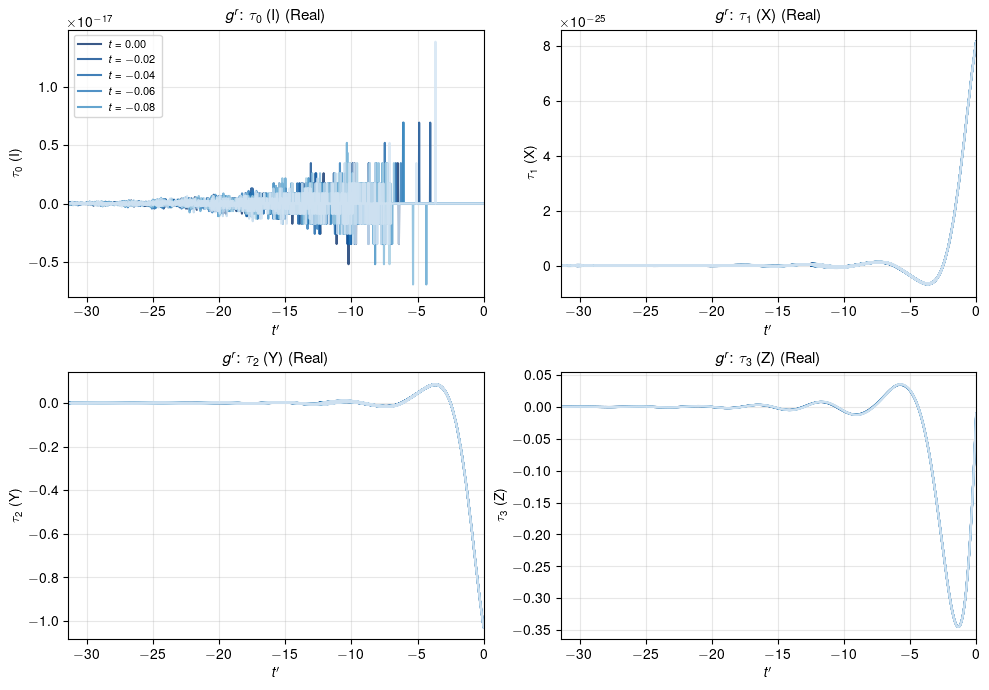

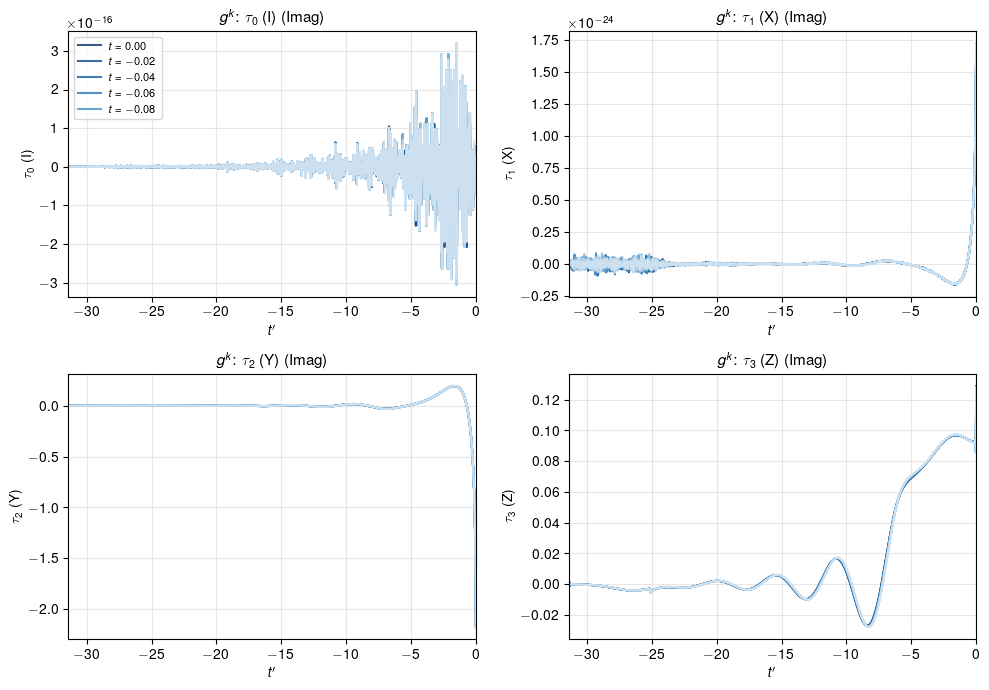


Time-Translation Invariance Results:
  gr max diffs per row: [0.0, np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023), np.float64(1.0390791997429023)]
  gr max diff: 1.04e+00 (in row 2 from last)

  gk max diffs per row: [0.0, np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153), np.float64(3.3971039711536153)]
  gk max diff: 3.40e+00 (in row 2 from last)

  Passed (threshold 1e-08): False


In [6]:
# Check time-translation invariance (equilibrium test)
tti_results = da.check_time_translational_invariance(check_timestamp, check_job_index,
                                                      num_rows=10, threshold=1e-8, save_plot=False)

print(f"\nTime-Translation Invariance Results:")
print(f"  gr max diffs per row: {tti_results['max_diff_gr']}")
gr_max_idx = np.argmax(tti_results['max_diff_gr'])
print(f"  gr max diff: {tti_results['max_diff_gr'][gr_max_idx]:.2e} (in row {gr_max_idx + 1} from last)")

print(f"\n  gk max diffs per row: {tti_results['max_diff_gk']}")
gk_max_idx = np.argmax(tti_results['max_diff_gk'])
print(f"  gk max diff: {tti_results['max_diff_gk'][gk_max_idx]:.2e} (in row {gk_max_idx + 1} from last)")

print(f"\n  Passed (threshold {tti_results['threshold']:.0e}): {tti_results['passed']}")

In [ ]:
# Check state evolution (initial vs final time)
evolution_results = da.check_state_evolution(check_timestamp, check_job_index, save_plot=False)

pauli_names = ['τ₀', 'τ₁', 'τ₂', 'τ₃']
print(f"\nState Evolution Check Results:")
print(f"  gr differences per channel (initial t=0 vs final t=-1):")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {evolution_results['gr_max_diff'][i]:.2e}")
gr_max_idx = np.argmax(evolution_results['gr_max_diff'])
print(f"  gr max diff: {evolution_results['gr_max_diff'][gr_max_idx]:.2e} (in channel {pauli_names[gr_max_idx]})")

print(f"\n  gk differences per channel (initial t=0 vs final t=-1):")
for i, name in enumerate(pauli_names):
    print(f"    {name}: {evolution_results['gk_max_diff'][i]:.2e}")
gk_max_idx = np.argmax(evolution_results['gk_max_diff'])
print(f"  gk max diff: {evolution_results['gk_max_diff'][gk_max_idx]:.2e} (in channel {pauli_names[gk_max_idx]})")

# 2. Gap and Current Analysis


Input Parameters (timestamp=1780778728, job_index=0):
  num_timesteps: 300
  system_parameters: {'critical_temperature': 1, 'temperature': 0.3, 'eta': 0.2}
  initial_state_timestamp: 1780759388
  initial_state_index: 0
  grid_parameters: {'time_sampling': 1501, 'time_duration': 31.41592653589793}
  driving_field: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.

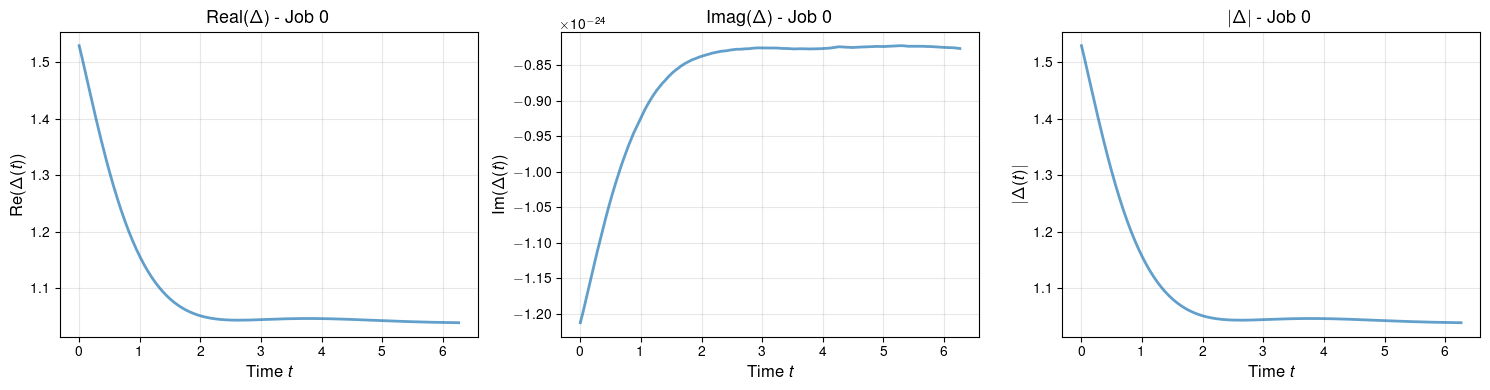

In [7]:
# Plot gap evolution for this job
da.plot_gap(check_timestamp, check_job_index, save_plot=False)


Input Parameters (timestamp=1780778728, job_index=0):
  num_timesteps: 300
  system_parameters: {'critical_temperature': 1, 'temperature': 0.3, 'eta': 0.2}
  initial_state_timestamp: 1780759388
  initial_state_index: 0
  grid_parameters: {'time_sampling': 1501, 'time_duration': 31.41592653589793}
  driving_field: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.

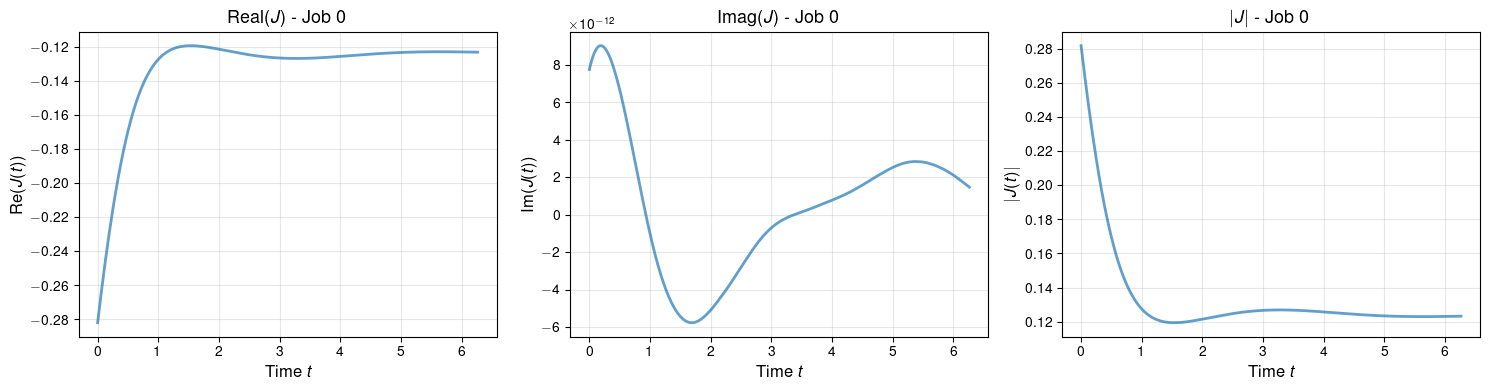

In [8]:
# Plot current evolution for this job
da.plot_current(check_timestamp, check_job_index, save_plot=False)

# 3. Parameter Sweep Analysis

Run this section to compare equilibrated gap/current across multiple timestamps.

In [9]:
# Define timestamps for parameter sweep comparison
sweep_timestamps = ['1780783363']  # Add more timestamps as needed: ['ts1', 'ts2', ...]

# Parameters to sweep over: 'temperature' or 'vector_potential'
sweep_parameter = 'temperature'

# Number of final timesteps to average for equilibration
n_average = 100

print(f"Parameter sweep over: {sweep_parameter}")
print(f"Timestamps to analyze: {sweep_timestamps}")
print(f"Averaging last {n_average} timesteps")

Parameter sweep over: temperature
Timestamps to analyze: ['1780783363']
Averaging last 100 timesteps


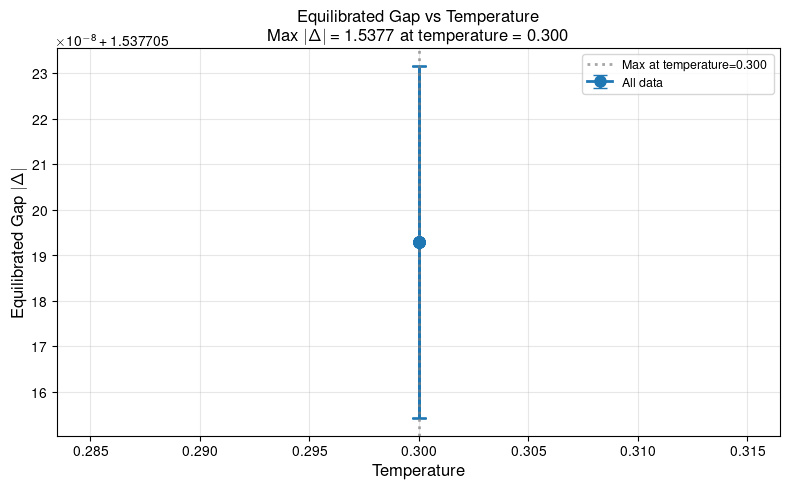


Gap Sweep Results:
  Parameter values: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
  Gap means: [1.53770519-1.24534791e-24j 1.53770519-1.24534791e-24j
 1.53770519-1.24534791e-24j 1.53770519-1.24534791e-24j
 1.53770519-1.24534791e-24j 1.53770519-1.24534791e-24j
 1.53770519-1.24534791e-24j 1.53770519-1.24534791e-24j]
  Gap errors: [3.86729541e-08 3.86729541e-08 3.86729541e-08 3.86729541e-08
 3.86729541e-08 3.86729541e-08 3.86729541e-08 3.86729541e-08]

Maximum Gap:
  Max |Δ| = 1.5377
  At temperature = 0.3000


In [10]:
# Plot equilibrated gap vs parameter
gap_sweep_results = da.plot_equilibrated_gap_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False, combine_timestamps = True
)

print(f"\nGap Sweep Results:")
print(f"  Parameter values: {gap_sweep_results['parameter_values']}")
print(f"  Gap means: {gap_sweep_results['gap_means']}")
print(f"  Gap errors: {gap_sweep_results['gap_errors']}")
print(f"\nMaximum Gap:")
print(f"  Max |Δ| = {gap_sweep_results['max_gap']:.4f}")
print(f"  At {sweep_parameter} = {gap_sweep_results['max_parameter']:.4f}")

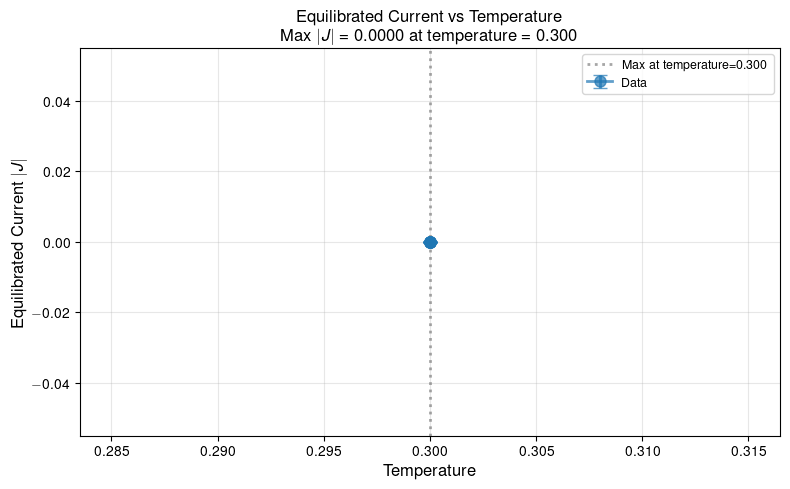


Current Sweep Results:
  Parameter values: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
  Current means: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
  Current errors: [0. 0. 0. 0. 0. 0. 0. 0.]

Maximum Current:
  Max |J| = 0.0000
  At temperature = 0.3000


In [11]:
# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False
)

print(f"\nCurrent Sweep Results:")
print(f"  Parameter values: {current_sweep_results['parameter_values']}")
print(f"  Current means: {current_sweep_results['current_means']}")
print(f"  Current errors: {current_sweep_results['current_errors']}")
print(f"\nMaximum Current:")
print(f"  Max |J| = {current_sweep_results['max_current']:.4f}")
print(f"  At {sweep_parameter} = {current_sweep_results['max_parameter']:.4f}")

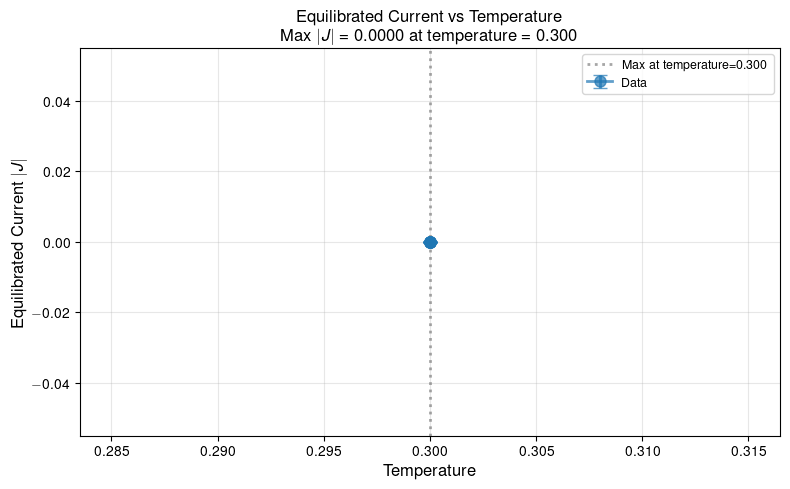


Current Sweep Results:
  Parameter values: [0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
  Current means: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
  Current errors: [0. 0. 0. 0. 0. 0. 0. 0.]

Maximum Current:
  Max |J| = 0.0000
  At temperature = 0.3000


In [12]:

# Plot equilibrated current vs parameter
current_sweep_results = da.plot_equilibrated_current_vs_parameter(
    sweep_timestamps,
    parameter=sweep_parameter,
    n_average=n_average,
    save_plot=False
)

print(f"\nCurrent Sweep Results:")
print(f"  Parameter values: {current_sweep_results['parameter_values']}")
print(f"  Current means: {current_sweep_results['current_means']}")
print(f"  Current errors: {current_sweep_results['current_errors']}")
print(f"\nMaximum Current:")
print(f"  Max |J| = {current_sweep_results['max_current']:.4f}")
print(f"  At {sweep_parameter} = {current_sweep_results['max_parameter']:.4f}")


